<a href="https://colab.research.google.com/github/lokeshp051/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lokeshp051/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
import duckdb
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
BASE = "hf://datasets/FlyRank/internship-warehouse"

## 1. Question

*The research question and the decision it supports.*

Research question: Which content pages are most likely to lose search visibility, and can a model rank them for reviewer prioritization better than a simple hand-written rule? Decision supported: which pages a content reviewer opens first each week, given limited review capacity.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data from the FlyRank Internship Warehouse Release (v20260703), table fact_content_daily_performance (daily grain, partitioned by month), joined with dim_content for static attributes. Analysis window: March 2026 (month=2026-03), a mid-panel month — the final month (June 2026) is treated as a sealed test set and was not used. Excluded: fact_content_query_90d (query-level data, out of scope) and AI-referral columns (relationship to decline not established). All content and client identifiers are pseudonymized hashes; no raw client names, domains, or queries appear anywhere in this analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label (proxy): is_declining_label = (impressions in second half of month < impressions in first half). Features: impressions_h1, clicks_h1, avg_position_h1, ctr_h1, word_count — all knowable before the decision point (first-half-of-month only). Baseline: a hand-written rule flagging pages ranking top-20 or better with below-median CTR for their position bucket (LOW_CTR_FOR_POSITION). Model: Decision Tree Classifier (max_depth=4, class_weight="balanced"). Validation: grouped by client (GroupShuffleSplit, 80/20) — no client's pages appear in both train and test, simulating deployment on unseen clients. Leakage check: confirmed no feature is a near-perfect proxy for the label-generating column (impressions_h2); highest correlation was impressions_h1 at 0.83, an expected autocorrelation, not leakage.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
import pandas as pd
results_df = pd.DataFrame([
    {"k": 20, "baseline_precision": 0.55, "model_precision": 0.50},
    {"k": 50, "baseline_precision": 0.56, "model_precision": 0.64},
    {"k": 100, "baseline_precision": 0.54, "model_precision": 0.68},
])
print(results_df)

     k  baseline_precision  model_precision
0   20                0.55             0.50
1   50                0.56             0.64
2  100                0.54             0.68


On the honest, client-grouped split: the baseline rule wins at Precision@20 (0.55 vs 0.50), but the model pulls ahead at Precision@50 (0.64 vs 0.56) and Precision@100 (0.68 vs 0.54). This matches an earlier finding from Week 2's toy example: a sharp hand rule can dominate the very top of a list, while a model that blends multiple signals performs better deeper into a queue — which matters more for reviewers who can check 50-100 pages.

## 5. Limitations

*What this work cannot claim.*

This is an observational, single-month analysis — correlations are not causal. The label is a proxy (impressions dropped within-month), not a verified business outcome. word_count carries unexpectedly high feature importance (0.42), possibly reflecting a correlated content-type effect rather than a direct causal lever. GA4 coverage in this slice is sparse (~4% of rows), limiting cross-source features. Results are specific to this portfolio slice and month; they should not be read as universal SEO claims.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The trained model + reason-code system ranks pages into three actionable tiers: HIGH_RISK_LOW_CTR → urgent refresh and snippet rewrite; HIGH_RISK_GENERAL → scheduled content refresh; LOW_CTR_FOR_POSITION → title/snippet review. All flagged pages require human review before any action — nothing here should be auto-published or auto-deleted. Recommended monitoring: track real impression change 30/60 days post-action against a matched control; retrain if Precision@50 drops meaningfully below 0.64 on fresh data, or quarterly regardless.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

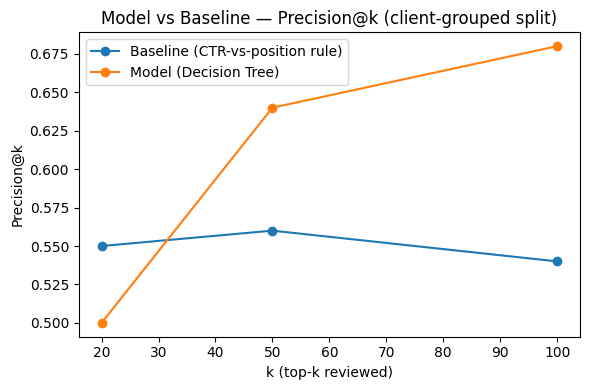

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
x = results_df["k"]
ax.plot(x, results_df["baseline_precision"], marker="o", label="Baseline (CTR-vs-position rule)")
ax.plot(x, results_df["model_precision"], marker="o", label="Model (Decision Tree)")
ax.set_xlabel("k (top-k reviewed)")
ax.set_ylabel("Precision@k")
ax.set_title("Model vs Baseline — Precision@k (client-grouped split)")
ax.legend()
plt.tight_layout()

import os
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.